# Section 4: Performance Metrics for Fraud Detection
### Lecture 16: Implementing Performance Metrics in scikit-learn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('../Modulo2/creditcard.csv.zip')
y = df['Class']
X = df.drop(['Class','Amount','Time'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
# dividir a classe de forma proporcional a classe 1 fraude (stratify)
model_xgb = xgb.XGBClassifier(max_depth=5, scale_pos_weight=100)
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[28426,     6],
       [    9,    40]])

In [2]:
model_xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 100,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

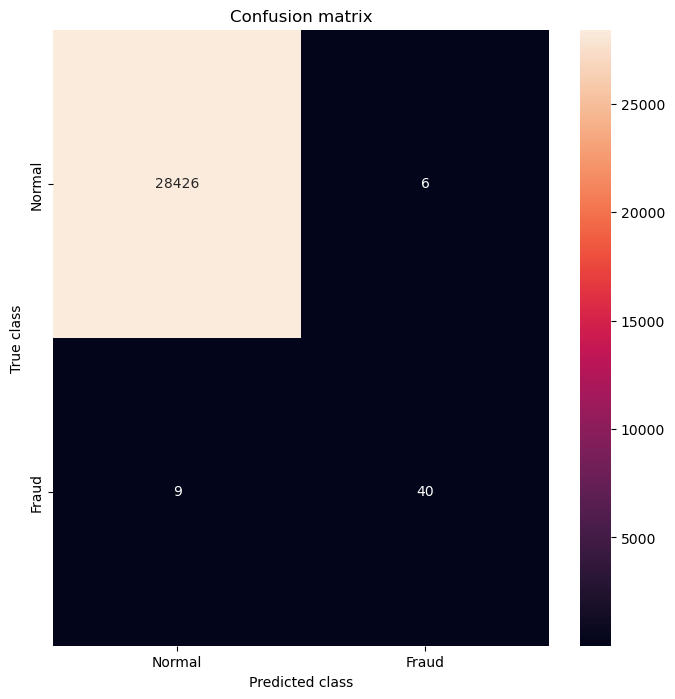

In [3]:

LABELS = ["Normal", "Fraud"]

conf_matrix_xgb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix_xgb, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

cálculo dos score

In [6]:
print('True negatives TN - actually non-fraudulent and correctly classified as non-fraudulent')
print(conf_matrix_xgb[0][0]) #normal 
print('False positives FP - actually non-fraudulent but incorrectly classified as fraud')
print(conf_matrix_xgb[0][1]) # normal but predicted fraud 
print('False negatives FN - actually fraud but incorrectly classified as being non-fraudulent')
print(conf_matrix_xgb[1][0]) # fraud but predicted normal 
print('True positives TP - actually fraud and correctly classified as fraud')
print(conf_matrix_xgb[1][1]) # Fraud 

True negatives TN - actually non-fraudulent and correctly classified as non-fraudulent
28426
False positives FP - actually non-fraudulent but incorrectly classified as fraud
6
False negatives FN - actually fraud but incorrectly classified as being non-fraudulent
9
True positives TP - actually fraud and correctly classified as fraud
40


In [4]:
from sklearn.metrics import (classification_report, precision_score, recall_score,
                             average_precision_score, roc_auc_score,
                             f1_score, matthews_corrcoef)                        

In [9]:
 40 / (40 + 6) 

0.8695652173913043

In [8]:
# Precision is the proportion of correctly predicted fraudulent instances among all instances predicted as fraud
# TP / TP + FP
# 40 / (40 + 6) = 0.8696

precision_score(y_test, y_pred)

0.8695652173913043

In [11]:
print('Precision is the proportion of correctly predicted fraudulent instances among all instances predicted as fraud')
print(f'{precision_score(y_test, y_pred)*100:.2f} %')

Precision is the proportion of correctly predicted fraudulent instances among all instances predicted as fraud
86.96 %


In [15]:
40 / (40 + 9 )

0.8163265306122449

In [12]:
# Recall is the proportion of the fraudulent instances that are successfully predicted
# TP / TP + FN
# 40 / (40 + 9 )= 0.8163

recall_score(y_test, y_pred)

0.8163265306122449

In [14]:
print('Recall is the proportion of the fraudulent instances that are successfully predicted')
print(f'{recall_score(y_test, y_pred)*100:.2f} %')

Recall is the proportion of the fraudulent instances that are successfully predicted
81.63 %


In [16]:
F = 2 * (0.8696 * 0.8163)/(0.8696+ 0.8163)
F

0.8421074559582419

In [17]:
# F1-score is the harmonic balance of precision and recall (can be weighted more towards P or R if need be)
# F = 2 * (Precision * Recall)/(Precision + Recall)
# F = 2 * (0.8696 * 0.8163)/(0.8696+ 0.8163)
# F = 0.8421

f1_score(y_test, y_pred)

0.8421052631578947

In [21]:
print('F1-score is the harmonic balance of precision and recall (can be weighted more towards P or R if need be)')
print(f'{f1_score(y_test, y_pred)*100:.2f} %')

F1-score is the harmonic balance of precision and recall (can be weighted more towards P or R if need be)
84.21 %


In [19]:
#FPR = FP / FP + TN
FPR = 6 / (6 + 28426)
FPR

0.00021102982554867754

In [20]:
# AUROC/AUC = Area under the Receiver Operating Characteristic curve
# plot the TPR (Recall) and FPR at various classification thresholds (limite)
# FPR = FP / FP + TN
# Good measure of overall performance

roc_auc_score(y_test, y_pred)

0.9080577503933481

In [26]:
texto =f"""AUROC/AUC = Area under the Receiver Operating Characteristic curve
plot the TPR (Recall) and FPR at various classification thresholds (limite)
{roc_auc_score(y_test, y_pred)*100:.2f} %
"""

In [27]:
print(texto)

AUROC/AUC = Area under the Receiver Operating Characteristic curve
plot the TPR (Recall) and FPR at various classification thresholds (limite)
90.81 %



In [28]:
# AUPRC = Area under the Precision-Recall curve
# Better alternative to AUC as doesn't include TN which influences the scores significantly in highly imbalanced data
# calculates the area under the curve at various classification thresholds

average_precision_score(y_test, y_pred)

0.7101651571945705

In [30]:
texto =f"""
AUPRC = Area under the Precision-Recall curve
Better alternative to AUC as doesn't include TN which influences the scores significantly in highly imbalanced data
calculates the area under the curve at various classification thresholds
{average_precision_score(y_test, y_pred)*100} %
"""
print(texto)


AUPRC = Area under the Precision-Recall curve
Better alternative to AUC as doesn't include TN which influences the scores significantly in highly imbalanced data
calculates the area under the curve at various classification thresholds
71.01651571945705 %



In [31]:
# Classification report summarizes the classification metrics at the class and overall level

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.87      0.82      0.84        49

    accuracy                           1.00     28481
   macro avg       0.93      0.91      0.92     28481
weighted avg       1.00      1.00      1.00     28481



What is a good performance metric to use for evaluating the effectiveness of our fraud detection models?

AUPRC







UPRC é uma métrica que considera tanto a precisão quanto o recall, oferecendo uma visão equilibrada do desempenho do modelo, especialmente em casos de classes desbalanceadas, sem ser influenciada negativamente pelo número de verdadeiros negativos. Isso a torna especialmente útil para avaliar a eficácia dos modelos de detecção de fraudes.
